In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df_read = pd.read_csv("/kaggle/input/next-pred/dam_price_forecast_next_day.csv")

In [10]:
predicted_prices = df_read["DAM_price_forecast"]

In [11]:
start_datetime = "2026-01-25 00:00:00"

In [12]:
E_max = 100.0        # Battery capacity in MWh
P_ch_max = 25.0      # Max charge power in MW
P_dis_max = 25.0     # Max discharge power in MW

eta_ch = 0.95
eta_dis = 0.95

SoC0 = 50.0          # initial SoC (MWh)

reserve_frac = 0.20  # 20% reserved for ancillary services
reserve_price = 150  # ₹/MW/hour (synthetic, you can change)

dt = 0.25            # 15 minutes = 0.25 hour

In [13]:
prices = np.array(predicted_prices)

low_threshold = np.percentile(prices, 30)     # bottom ~30% -> charge zone
high_threshold = np.percentile(prices, 70)    # top ~30% -> discharge zone

avg_low = prices[prices <= low_threshold].mean()
avg_high = prices[prices >= high_threshold].mean()

In [8]:
E_reserve = reserve_frac * E_max
P_reserve = reserve_frac * min(P_ch_max, P_dis_max)

# ancillary payment per 15 min block
ancillary_revenue_per_block = P_reserve * reserve_price * dt

In [14]:
def run_battery_dispatch(prices, start_datetime):
    n = len(prices)

    # timeline
    ts = pd.date_range(start=start_datetime, periods=n, freq="15min")

    # storage arrays
    SoC = np.zeros(n + 1)
    SoC[0] = SoC0

    charge_MWh = np.zeros(n)
    discharge_MWh = np.zeros(n)

    action = ["IDLE"] * n
    arbitrage_profit = np.zeros(n)
    ancillary_revenue = np.zeros(n)

    for t in range(n):
        p = prices[t]

        # reserve band constraints
        soc_min = E_reserve
        soc_max = E_max - E_reserve

        # clamp SoC
        SoC[t] = np.clip(SoC[t], soc_min, soc_max)

        # how much can we charge/discharge this block
        max_charge_possible = min(P_ch_max * dt, soc_max - SoC[t])  # MWh
        max_dis_possible = min(P_dis_max * dt, SoC[t] - soc_min)    # MWh

        # ----------------------------------------------------
        # Decision logic: compare arbitrage vs ancillary value
        # ----------------------------------------------------

        # Candidate DISCHARGE when price high
        if p >= high_threshold and max_dis_possible > 0:
            profit_per_MWh = max(p - avg_low, 0)  # expected margin vs cheap buy
            arb_value = profit_per_MWh * max_dis_possible  # ₹ (rough)

            if arb_value > ancillary_revenue_per_block:
                # DISCHARGE
                E_dis = max_dis_possible
                discharge_MWh[t] = E_dis
                SoC[t + 1] = SoC[t] - (E_dis / eta_dis)

                arbitrage_profit[t] = E_dis * p
                action[t] = "DISCHARGE"
            else:
                # ANCILLARY
                SoC[t + 1] = SoC[t]
                ancillary_revenue[t] = ancillary_revenue_per_block
                action[t] = "ANCILLARY"

        # Candidate CHARGE when price low
        elif p <= low_threshold and max_charge_possible > 0:
            # only charge if there are high prices later
            if avg_high > p * 1.05:
                E_ch = max_charge_possible
                charge_MWh[t] = E_ch
                SoC[t + 1] = SoC[t] + (E_ch * eta_ch)

                arbitrage_profit[t] = -E_ch * p
                action[t] = "CHARGE"
            else:
                SoC[t + 1] = SoC[t]
                ancillary_revenue[t] = ancillary_revenue_per_block
                action[t] = "ANCILLARY"

        else:
            # Mid zone => keep reserve and earn payment
            SoC[t + 1] = SoC[t]
            ancillary_revenue[t] = ancillary_revenue_per_block
            action[t] = "ANCILLARY"

        # clamp next SoC too
        SoC[t + 1] = np.clip(SoC[t + 1], soc_min, soc_max)

    # Build dataframe
    df = pd.DataFrame({
        "timestamp": ts,
        "time_block": np.arange(1, n + 1),
        "price_Rs_per_MWh": prices,
        "action": action,
        "charge_MWh": charge_MWh,
        "discharge_MWh": discharge_MWh,
        "SoC_MWh": SoC[1:],
        "arbitrage_profit_Rs": arbitrage_profit,
        "ancillary_revenue_Rs": ancillary_revenue,
        "total_revenue_Rs": arbitrage_profit + ancillary_revenue
    })

    return df, SoC

In [15]:
dispatch_df, soc_series = run_battery_dispatch(predicted_prices, start_datetime)

In [16]:
buy_points = dispatch_df[dispatch_df["action"] == "CHARGE"][
    ["time_block", "timestamp", "price_Rs_per_MWh", "charge_MWh"]
].reset_index(drop=True)

sell_points = dispatch_df[dispatch_df["action"] == "DISCHARGE"][
    ["time_block", "timestamp", "price_Rs_per_MWh", "discharge_MWh"]
].reset_index(drop=True)

In [17]:
total_arbitrage_profit = dispatch_df["arbitrage_profit_Rs"].sum()
total_ancillary_revenue = dispatch_df["ancillary_revenue_Rs"].sum()
total_revenue = dispatch_df["total_revenue_Rs"].sum()

In [18]:
print("\n==================== ✅ RESULTS SUMMARY ====================")
print("Arbitrage Profit (₹):", round(total_arbitrage_profit, 2))
print("Ancillary Revenue (₹):", round(total_ancillary_revenue, 2))
print("TOTAL Revenue (₹):", round(total_revenue, 2))
print("===========================================================\n")

print("✅ BUY (CHARGE) Points:")
display(buy_points)

print("✅ SELL (DISCHARGE) Points:")
display(sell_points)


==================== ✅ RESULTS SUMMARY ====================
Arbitrage Profit (₹): 521602.58
Ancillary Revenue (₹): 8812.5
TOTAL Revenue (₹): 530415.08

✅ BUY (CHARGE) Points:


,time_block,timestamp,price_Rs_per_MWh,charge_MWh
0,3,2026-01-25 00:30:00,2608.4114,6.250000e+00
1,4,2026-01-25 00:45:00,2605.8533,6.250000e+00
2,5,2026-01-25 01:00:00,2608.4114,6.250000e+00
3,6,2026-01-25 01:15:00,2624.0706,6.250000e+00
4,7,2026-01-25 01:30:00,2618.3850,6.250000e+00
5,8,2026-01-25 01:45:00,2623.2944,3.125000e-01
6,9,2026-01-25 02:00:00,2608.4114,1.562500e-02
7,10,2026-01-25 02:15:00,2605.8533,7.812500e-04
8,11,2026-01-25 02:30:00,2608.8050,3.906250e-05
9,12,2026-01-25 02:45:00,2598.2913,1.953125e-06


✅ SELL (DISCHARGE) Points:


,time_block,timestamp,price_Rs_per_MWh,discharge_MWh
0,26,2026-01-25 06:15:00,3900.8200,6.250000
1,27,2026-01-25 06:30:00,4318.7410,6.250000
2,28,2026-01-25 06:45:00,4337.1655,6.250000
3,29,2026-01-25 07:00:00,6711.7905,6.250000
4,30,2026-01-25 07:15:00,6832.3540,6.250000
5,31,2026-01-25 07:30:00,8900.9795,6.250000
6,32,2026-01-25 07:45:00,9117.0860,6.250000
7,33,2026-01-25 08:00:00,8883.6060,6.250000
8,34,2026-01-25 08:15:00,6920.7890,6.250000
9,35,2026-01-25 08:30:00,6318.2400,0.789474


In [19]:
print("\n==================== ✅ RESULTS SUMMARY ====================")
print("Arbitrage Profit (₹):", round(total_arbitrage_profit, 2))
print("Ancillary Revenue (₹):", round(total_ancillary_revenue, 2))
print("TOTAL Revenue (₹):", round(total_revenue, 2))
print("===========================================================\n")

print("✅ BUY (CHARGE) Points:")
display(buy_points)

print("✅ SELL (DISCHARGE) Points:")
display(sell_points)


==================== ✅ RESULTS SUMMARY ====================
Arbitrage Profit (₹): 521602.58
Ancillary Revenue (₹): 8812.5
TOTAL Revenue (₹): 530415.08

✅ BUY (CHARGE) Points:


,time_block,timestamp,price_Rs_per_MWh,charge_MWh
0,3,2026-01-25 00:30:00,2608.4114,6.250000e+00
1,4,2026-01-25 00:45:00,2605.8533,6.250000e+00
2,5,2026-01-25 01:00:00,2608.4114,6.250000e+00
3,6,2026-01-25 01:15:00,2624.0706,6.250000e+00
4,7,2026-01-25 01:30:00,2618.3850,6.250000e+00
5,8,2026-01-25 01:45:00,2623.2944,3.125000e-01
6,9,2026-01-25 02:00:00,2608.4114,1.562500e-02
7,10,2026-01-25 02:15:00,2605.8533,7.812500e-04
8,11,2026-01-25 02:30:00,2608.8050,3.906250e-05
9,12,2026-01-25 02:45:00,2598.2913,1.953125e-06


✅ SELL (DISCHARGE) Points:


,time_block,timestamp,price_Rs_per_MWh,discharge_MWh
0,26,2026-01-25 06:15:00,3900.8200,6.250000
1,27,2026-01-25 06:30:00,4318.7410,6.250000
2,28,2026-01-25 06:45:00,4337.1655,6.250000
3,29,2026-01-25 07:00:00,6711.7905,6.250000
4,30,2026-01-25 07:15:00,6832.3540,6.250000
5,31,2026-01-25 07:30:00,8900.9795,6.250000
6,32,2026-01-25 07:45:00,9117.0860,6.250000
7,33,2026-01-25 08:00:00,8883.6060,6.250000
8,34,2026-01-25 08:15:00,6920.7890,6.250000
9,35,2026-01-25 08:30:00,6318.2400,0.789474


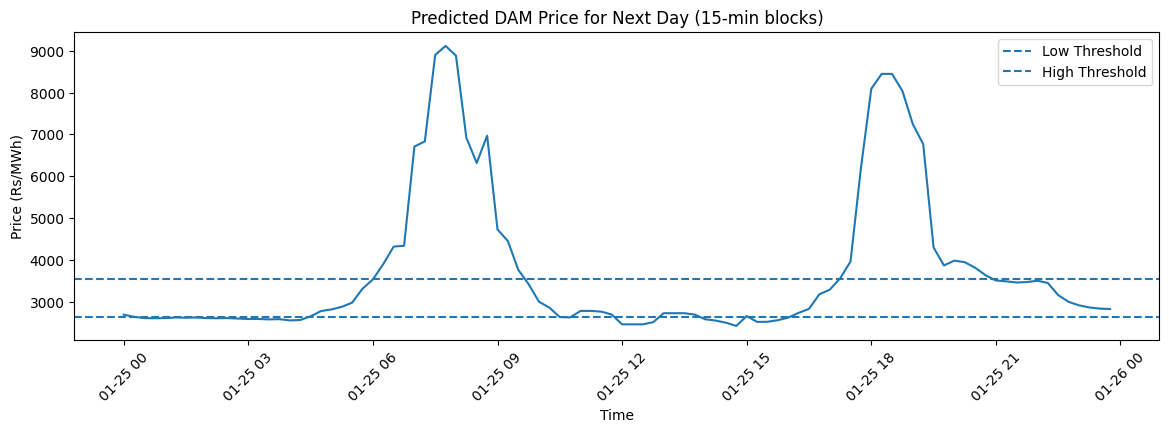

In [20]:
# Price curve
plt.figure(figsize=(14, 4))
plt.plot(dispatch_df["timestamp"], dispatch_df["price_Rs_per_MWh"])
plt.axhline(low_threshold, linestyle="--", label="Low Threshold")
plt.axhline(high_threshold, linestyle="--", label="High Threshold")
plt.title("Predicted DAM Price for Next Day (15-min blocks)")
plt.xlabel("Time")
plt.ylabel("Price (Rs/MWh)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

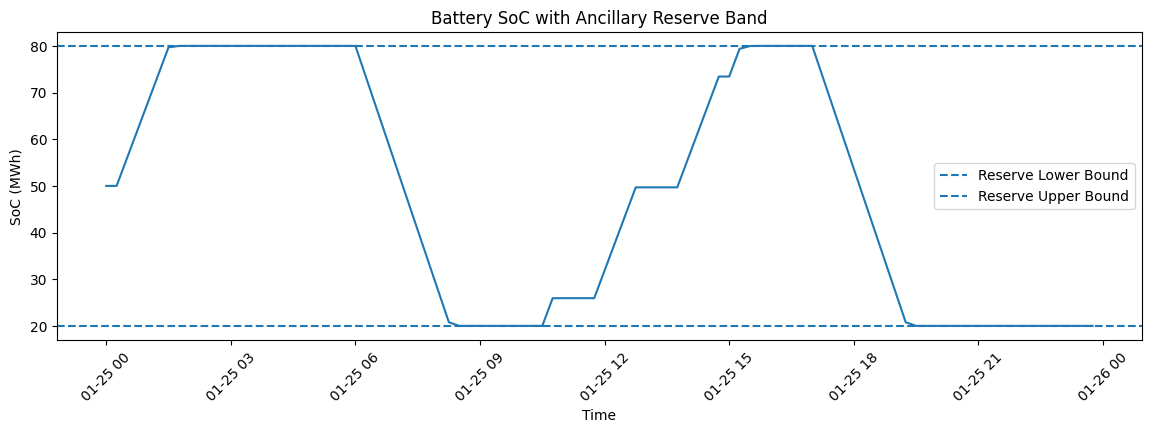

In [21]:
plt.figure(figsize=(14, 4))
plt.plot(dispatch_df["timestamp"], dispatch_df["SoC_MWh"])
plt.axhline(E_reserve, linestyle="--", label="Reserve Lower Bound")
plt.axhline(E_max - E_reserve, linestyle="--", label="Reserve Upper Bound")
plt.title("Battery SoC with Ancillary Reserve Band")
plt.xlabel("Time")
plt.ylabel("SoC (MWh)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

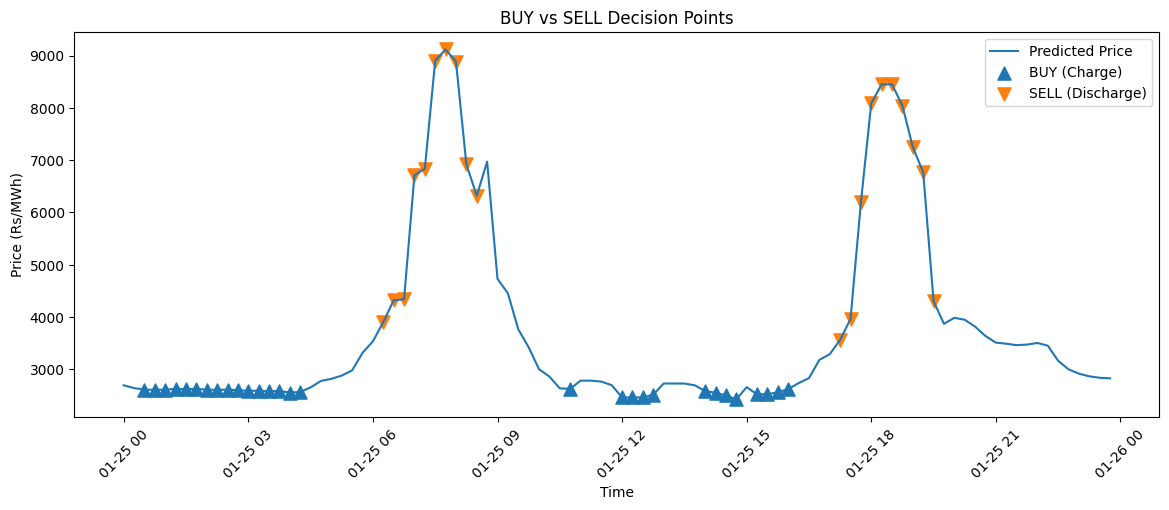

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(dispatch_df["timestamp"], dispatch_df["price_Rs_per_MWh"], label="Predicted Price")

if len(buy_points) > 0:
    plt.scatter(buy_points["timestamp"], buy_points["price_Rs_per_MWh"],
                marker="^", s=90, label="BUY (Charge)")

if len(sell_points) > 0:
    plt.scatter(sell_points["timestamp"], sell_points["price_Rs_per_MWh"],
                marker="v", s=90, label="SELL (Discharge)")

plt.title("BUY vs SELL Decision Points")
plt.xlabel("Time")
plt.ylabel("Price (Rs/MWh)")
plt.xticks(rotation=45)
plt.legend()
plt.show()


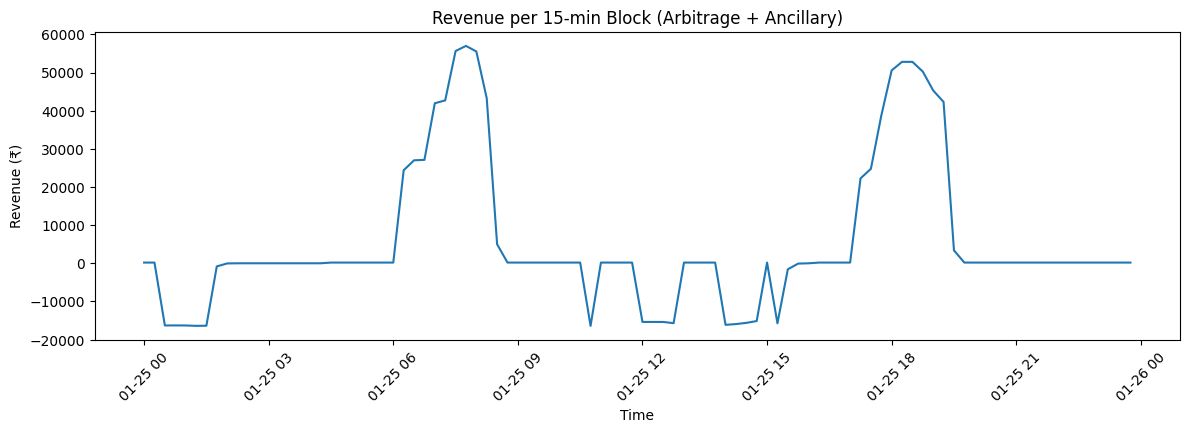

In [23]:
plt.figure(figsize=(14, 4))
plt.plot(dispatch_df["timestamp"], dispatch_df["total_revenue_Rs"])
plt.title("Revenue per 15-min Block (Arbitrage + Ancillary)")
plt.xlabel("Time")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.show()